# zoom images by a given factor

In [58]:
def normalized_ssd(img1, img2):
    # Normalize to [0,1] for fair comparison
    img1_norm = img1.astype(np.float32) / 255.0
    img2_norm = img2.astype(np.float32) / 255.0
    diff = img1_norm - img2_norm
    ssd = np.sum(diff ** 2)
    norm_factor = img1.size
    return ssd / norm_factor

In [37]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [71]:
# Load images
original_image1 = cv2.imread(r"C:\Users\Luchitha\Documents\Python\computer vision\Assignment1\q5images\im01.png")
zoomed_out_image1 = cv2.imread(r"C:\Users\Luchitha\Documents\Python\computer vision\Assignment1\q5images\im01small.png")
original_image2 = cv2.imread(r"C:\Users\Luchitha\Documents\Python\computer vision\Assignment1\q5images\im02.png")
zoomed_out_image2 = cv2.imread(r"C:\Users\Luchitha\Documents\Python\computer vision\Assignment1\q5images\im02small.png")
original_image3 = cv2.imread(r"C:\Users\Luchitha\Documents\Python\computer vision\Assignment1\q5images\im03.png")
zoomed_out_image3 = cv2.imread(r"C:\Users\Luchitha\Documents\Python\computer vision\Assignment1\q5images\im03small.png") 
original_image4 = cv2.imread(r"C:\Users\Luchitha\Documents\Python\computer vision\Assignment1\q5images\taylor.jpg")
zoomed_out_image4 = cv2.imread(r"C:\Users\Luchitha\Documents\Python\computer vision\Assignment1\q5images\taylor_small.jpg")

very_small_image = cv2.imread(r"C:\Users\Luchitha\Documents\Python\computer vision\Assignment1\q5images\taylor_very_small.jpg")

In [60]:
print("Original Image 1 shape:", original_image1.shape)
print("Zoomed-Out Image 1 shape:", zoomed_out_image1.shape)
print("Original Image 2 shape:", original_image2.shape)
print("Zoomed-Out Image 2 shape:", zoomed_out_image2.shape)
print("Original Image 3 shape:", original_image3.shape)
print("Zoomed-Out Image 3 shape:", zoomed_out_image3.shape)
print("Original Image 4 shape:", original_image4.shape)
print("Zoomed-Out Image 4 shape:", zoomed_out_image4.shape)

Original Image 1 shape: (1080, 1920, 3)
Zoomed-Out Image 1 shape: (270, 480, 3)
Original Image 2 shape: (1200, 1920, 3)
Zoomed-Out Image 2 shape: (300, 480, 3)
Original Image 3 shape: (1459, 2400, 3)
Zoomed-Out Image 3 shape: (365, 600, 3)
Original Image 4 shape: (560, 1000, 3)
Zoomed-Out Image 4 shape: (112, 200, 3)


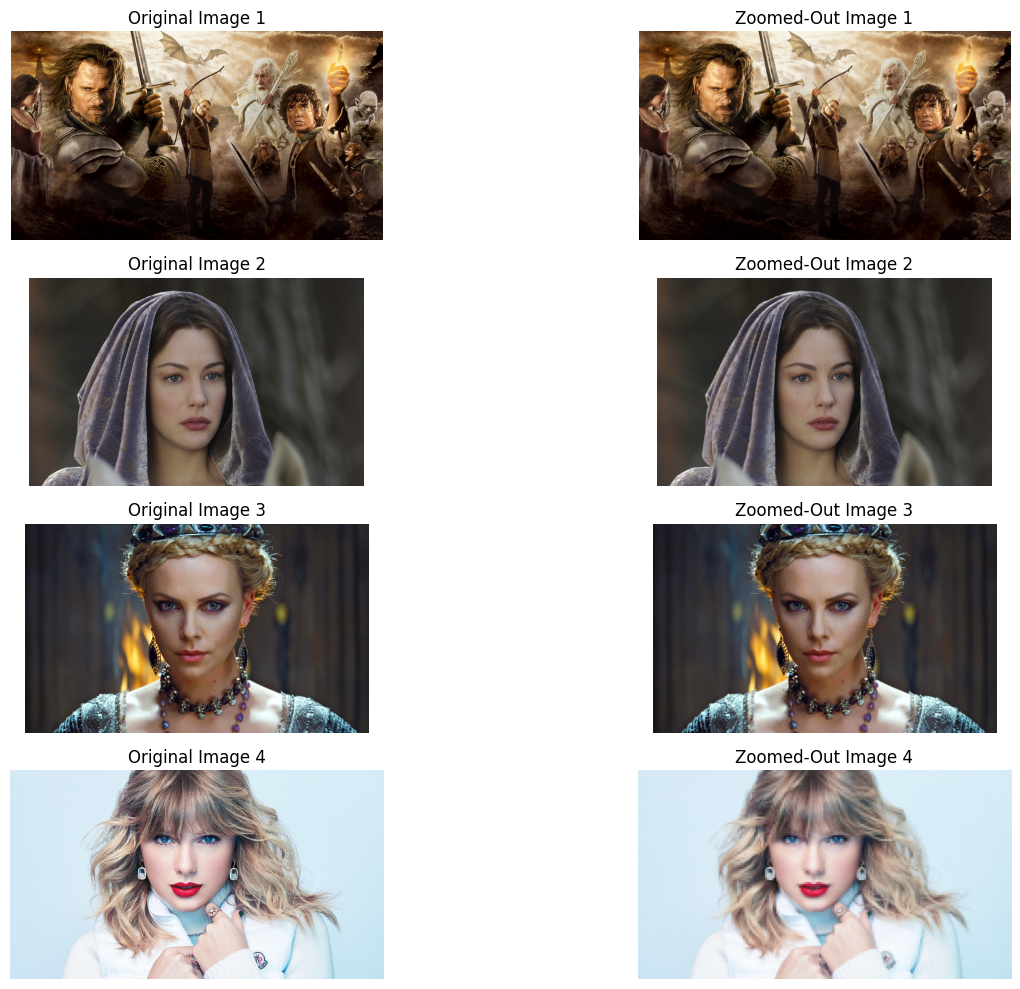

In [66]:



plt.figure(figsize=(15, 10))


plt.subplot(4, 2, 1)
plt.imshow(cv2.cvtColor(original_image1, cv2.COLOR_BGR2RGB))
plt.title('Original Image 1')
plt.axis('off')


plt.subplot(4, 2, 2)
plt.imshow(cv2.cvtColor(zoomed_out_image1, cv2.COLOR_BGR2RGB))
plt.title('Zoomed-Out Image 1')
plt.axis('off')


plt.subplot(4, 2, 3)
plt.imshow(cv2.cvtColor(original_image2, cv2.COLOR_BGR2RGB))
plt.title('Original Image 2')
plt.axis('off')


plt.subplot(4, 2, 4)
plt.imshow(cv2.cvtColor(zoomed_out_image2, cv2.COLOR_BGR2RGB))
plt.title('Zoomed-Out Image 2')
plt.axis('off')


plt.subplot(4, 2, 5)
plt.imshow(cv2.cvtColor(original_image3, cv2.COLOR_BGR2RGB))
plt.title('Original Image 3')
plt.axis('off')


plt.subplot(4, 2, 6)
plt.imshow(cv2.cvtColor(zoomed_out_image3, cv2.COLOR_BGR2RGB))
plt.title('Zoomed-Out Image 3')
plt.axis('off')

plt.subplot(4, 2, 7)
plt.imshow(cv2.cvtColor(original_image4, cv2.COLOR_BGR2RGB))
plt.title('Original Image 4')
plt.axis('off')

plt.subplot(4, 2, 8)
plt.imshow(cv2.cvtColor(zoomed_out_image4, cv2.COLOR_BGR2RGB))
plt.title('Zoomed-Out Image 4')
plt.axis('off')

plt.tight_layout()
plt.show()

(a)Nearest Neighbor method

In [78]:
# Zoom an image using nearest-neighbor interpolation.
def zoom_image_nearest(img, scale):
    new_size = (int(img.shape[1] * scale), int(img.shape[0] * scale))
    return cv2.resize(img, new_size, interpolation=cv2.INTER_NEAREST)

In [82]:
def NearestNeighbor(original, ZoomedOut, scale = 4):
    zoomed = zoom_image_nearest(ZoomedOut, scale)
    original = cv2.resize(original, (zoomed.shape[1], zoomed.shape[0]))#im03,taylor and im03small, taylor_small have mismatched sizes
    ssd = normalized_ssd(original, zoomed)
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.axis('off')
    plt.subplot(1, 3, 2)
    plt.imshow(cv2.cvtColor(zoomed, cv2.COLOR_BGR2RGB))
    plt.title('Zoomed Image')
    plt.axis('off')
    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(ZoomedOut, cv2.COLOR_BGR2RGB))
    plt.title('Zoomed-Out Image')
    plt.axis('off')
    
    plt.suptitle(f'SSD: {ssd:.4f}')
    plt.tight_layout()
    plt.show()

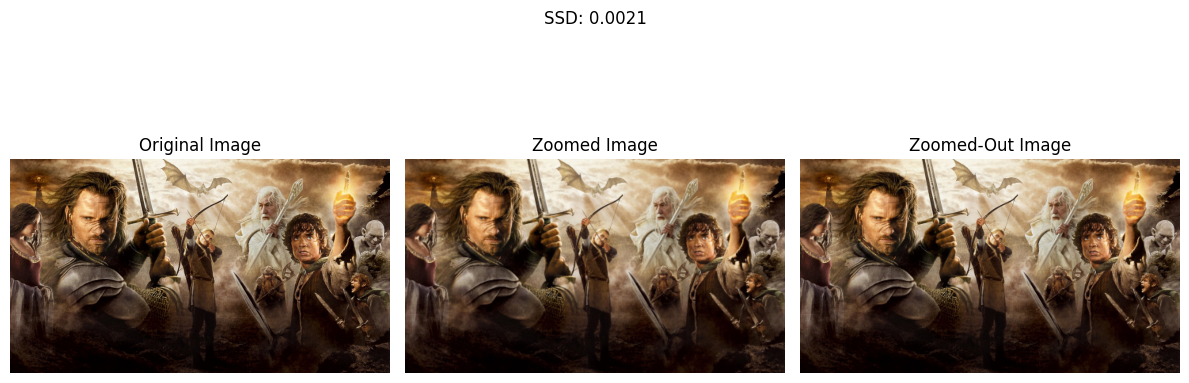

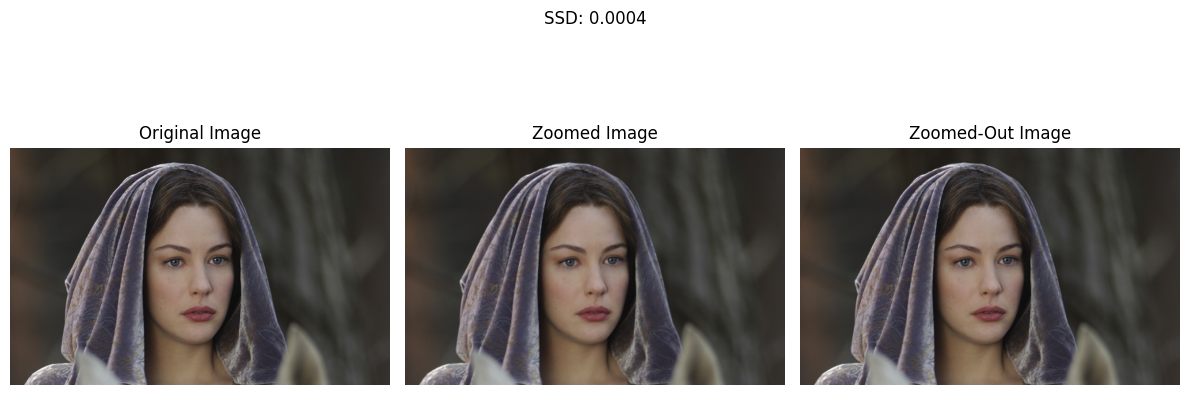

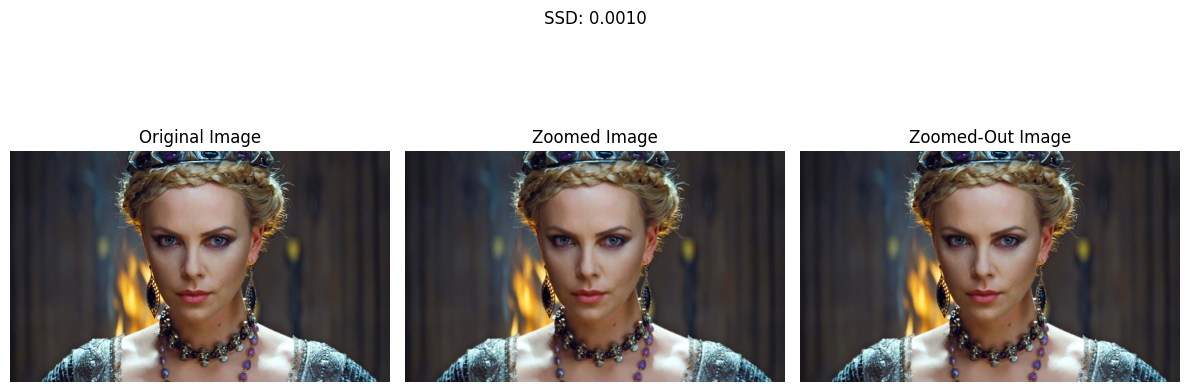

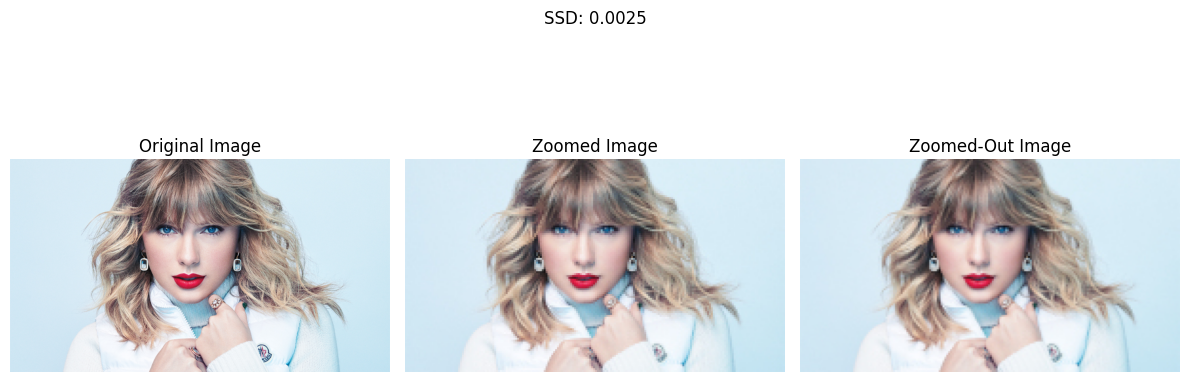

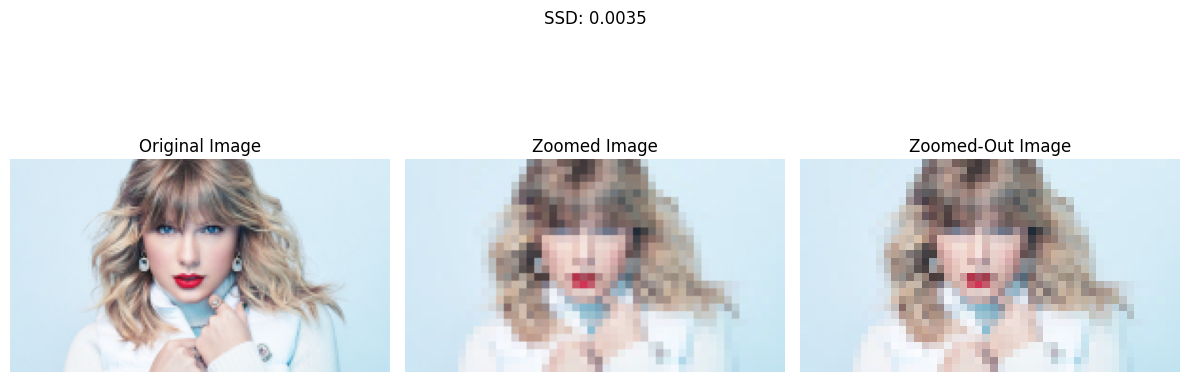

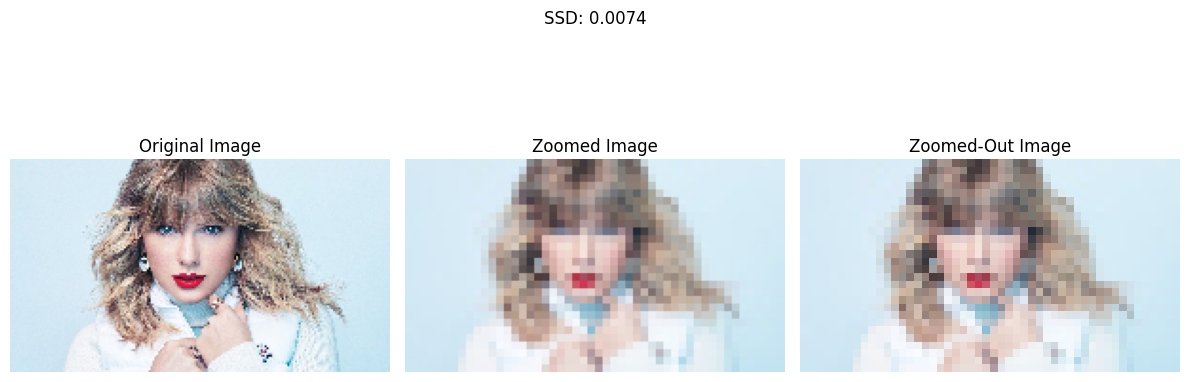

In [83]:
NearestNeighbor(original_image1, zoomed_out_image1)
NearestNeighbor(original_image2, zoomed_out_image2)
NearestNeighbor(original_image3, zoomed_out_image3) 
NearestNeighbor(original_image4, zoomed_out_image4)
NearestNeighbor(zoomed_out_image4, very_small_image)  # For the very small image
NearestNeighbor(original_image4, very_small_image)  # For the very small image

(b) Bilinear method

In [75]:
def zoom_image_bilinear(img, scale):
    new_size = (int(img.shape[1] * scale), int(img.shape[0] * scale))
    return cv2.resize(img, new_size, interpolation=cv2.INTER_LINEAR)


In [84]:
def bilinear(original, zoomed_out, scale=4):
    zoomed = zoom_image_bilinear(zoomed_out, scale)
    original = cv2.resize(original, (zoomed.shape[1], zoomed.shape[0]))  # Resize original to match zoomed(im03 and aylor images have mismatched sizes)
    ssd = normalized_ssd(original, zoomed)
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(cv2.cvtColor(zoomed, cv2.COLOR_BGR2RGB))
    plt.title('Zoomed Image')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(zoomed_out, cv2.COLOR_BGR2RGB))
    plt.title('Zoomed-Out Image')
    plt.axis('off')
    
    plt.suptitle(f'SSD: {ssd:.4f}')
    plt.tight_layout()
    plt.show()

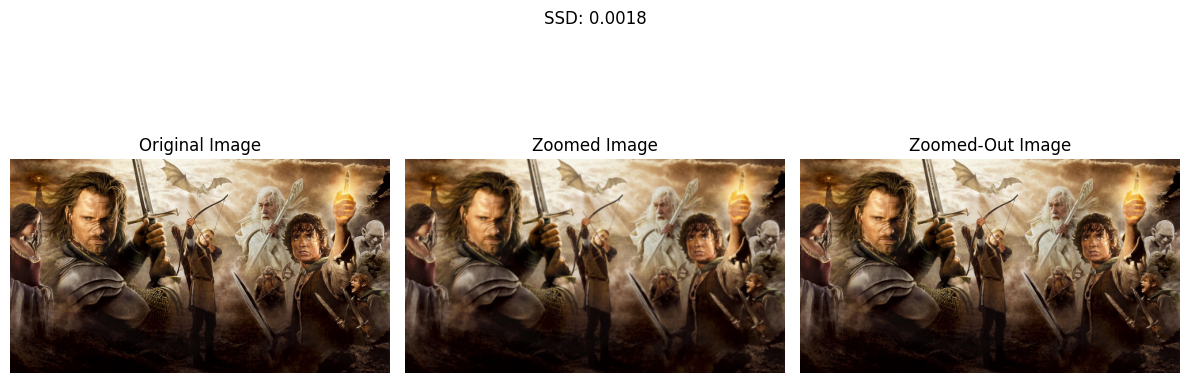

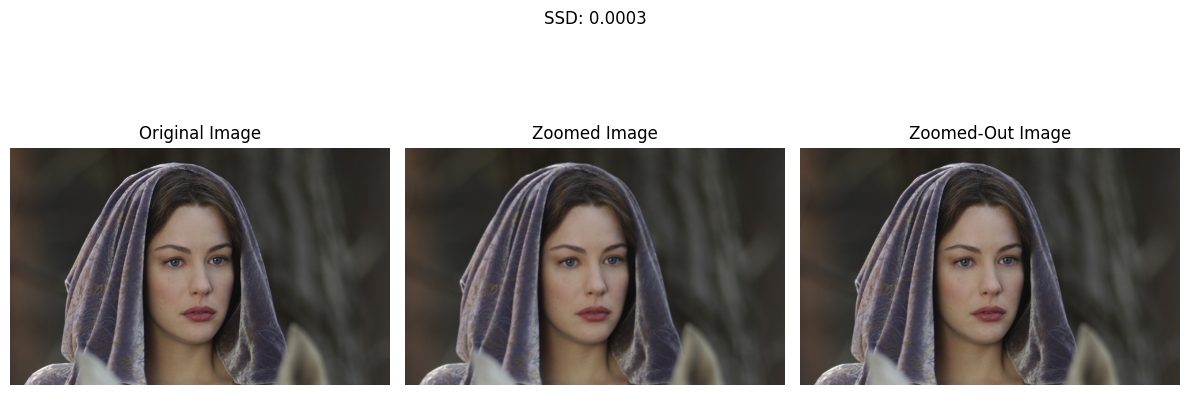

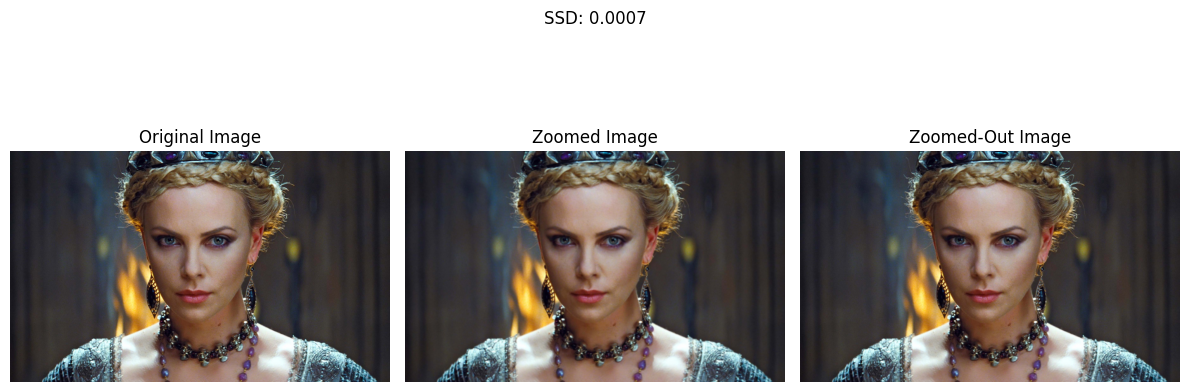

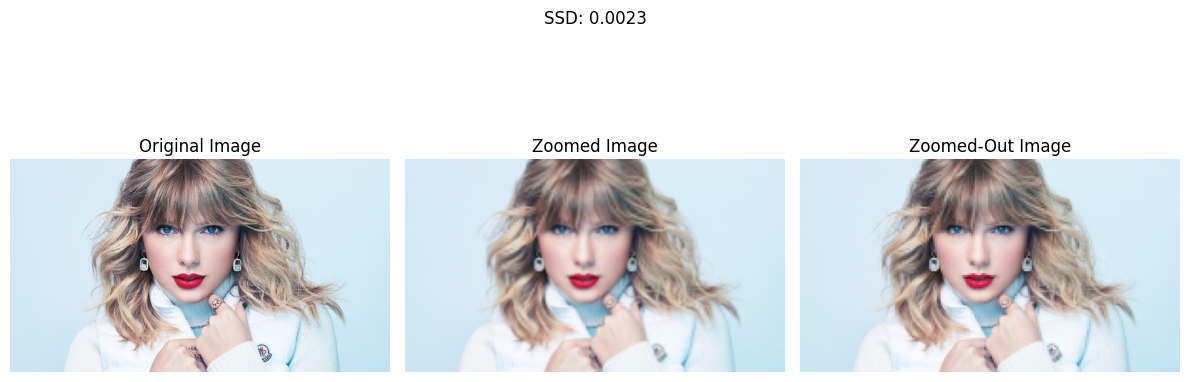

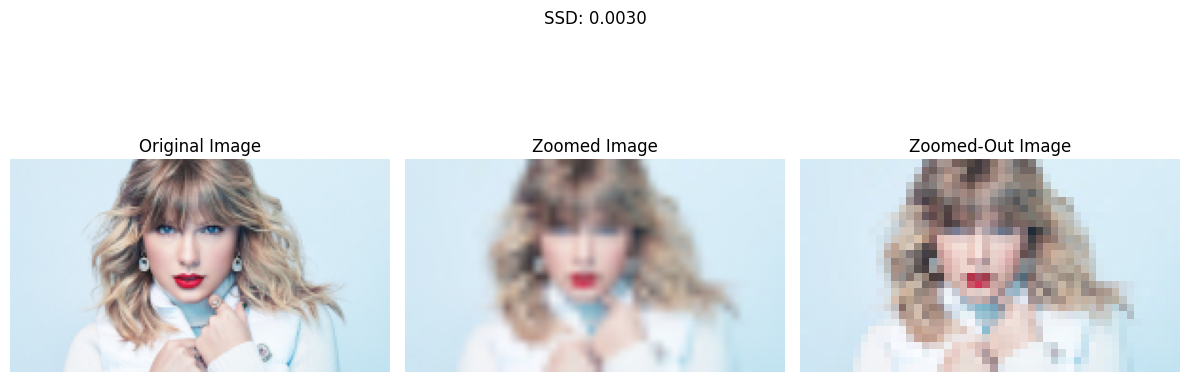

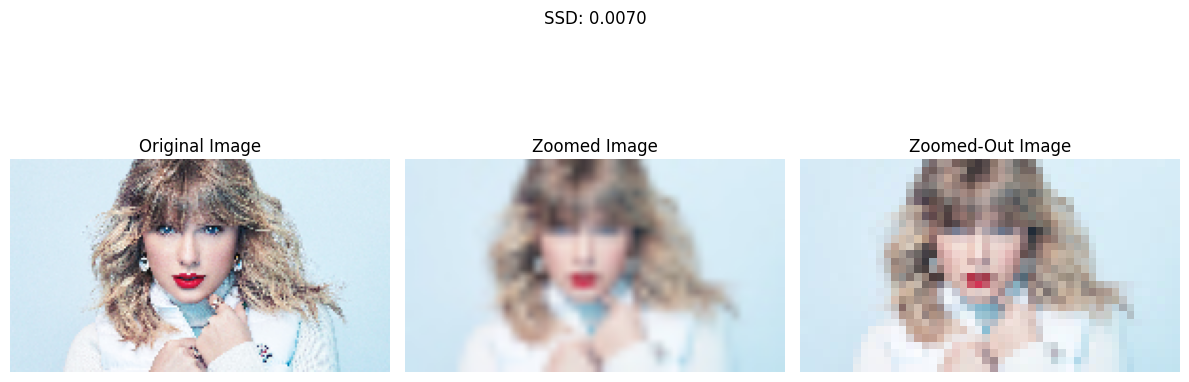

In [85]:
bilinear(original_image1, zoomed_out_image1)
bilinear(original_image2, zoomed_out_image2)
bilinear(original_image3, zoomed_out_image3)
bilinear(original_image4, zoomed_out_image4)
bilinear(zoomed_out_image4, very_small_image)  # For the very small image
bilinear(original_image4, very_small_image)  # For the very small image